### 📘 Deep Learning Autoencoder Project

`Image Denoising using Autoencoder (MNIST)`

**Assignment Topic:** Design and implement a Deep Learning Autoencoder that removes noise from MNIST handwritten digit images and reconstructs clean images.

### 🧠 Problem Statement

`Build a convolutional autoencoder that learns to reconstruct clean MNIST images from noisy input images. The model should be trained on noisy images while using the original clean images as targets. Finally, evaluate the reconstruction quality using sample predictions.`

---

Importing Required Libraries

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D

from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

Loading MNIST Dataset

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()
print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


Data Pre-Processing

In [3]:
# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (60000, 28, 28, 1)
Test Shape  : (10000, 28, 28, 1)


Adding Noise To Images

In [4]:
noise_factor = 0.5

# Generate noisy train images
X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

# Generate noisy test images
X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
)

# Clip pixel values
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

Visualizing Noisy Images

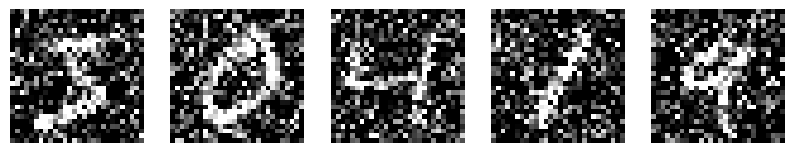

In [5]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

Build Convolutional Autoencoder

In [6]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2,2), padding="same")(x)
x = Conv2D(16, (3,3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2,2), padding="same")(x)

# Decoder
x = Conv2D(16, (3,3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)
autoencoder = Model(input_img, decoded)
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Training The Model

In [7]:
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.1929 - val_loss: 0.1278
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.1215 - val_loss: 0.1187
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1150 - val_loss: 0.1146
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1114 - val_loss: 0.1116
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1090 - val_loss: 0.1096
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1073 - val_loss: 0.1081
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1059 - val_loss: 0.1068
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1048 - val_loss: 0.1057
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1039 - val_loss: 0.1049
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1031 - val_loss: 0.1041


Ploting Training Loss

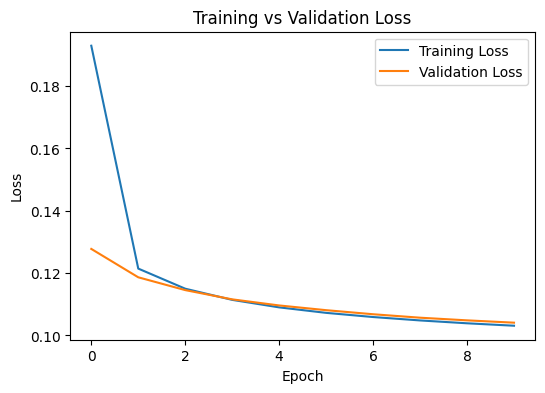

In [8]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Predicting Denoised Images

In [9]:
decoded_images = autoencoder.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Display Original, Noisy and Denoised Images

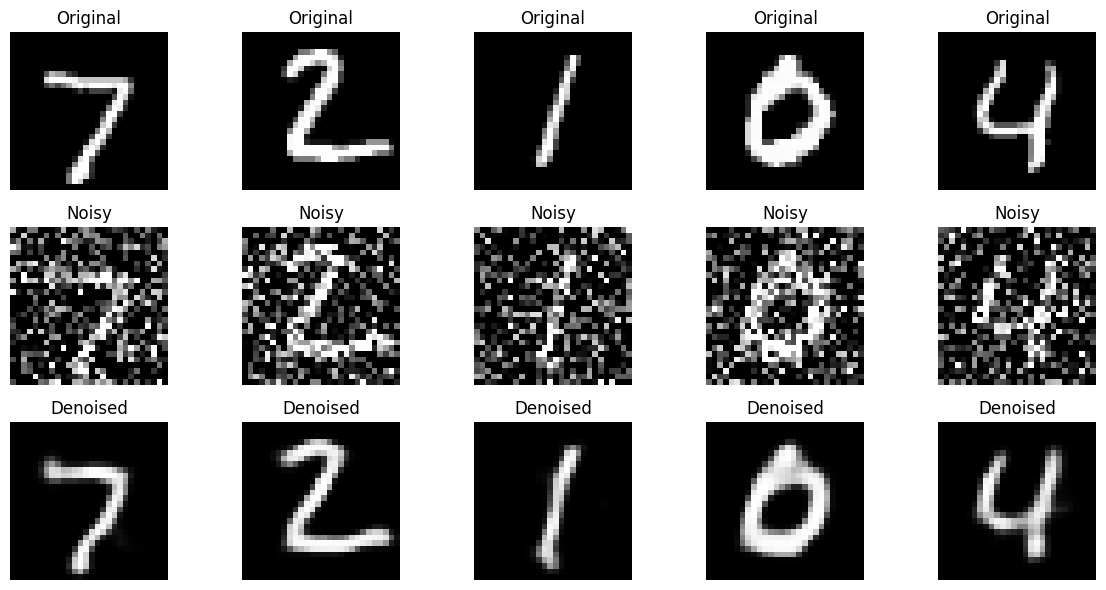

In [10]:
n = 5
plt.figure(figsize=(12,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_images[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

Model Evaluation

In [11]:
loss = autoencoder.evaluate(
    X_test_noisy,
    X_test,
    verbose=0
)
print("Test Loss :", loss)

Test Loss : 0.1021287590265274


### Conclusion

`The convolutional autoencoder successfully learned to reconstruct clean MNIST handwritten digit images from noisy inputs. The reconstructed images demonstrate effective noise removal while preserving the essential digit structure, making autoencoders suitable for image denoising tasks.`

---
### 🏁 Submission Checklist

- ✅ Markdown are used with proper description.
- ✅ All plots render with labels and titles.
- ✅ Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Saved as:** `week6_Amulya_Shrivastava.ipynb`